# Credible Answers to Hard Questions: Differences-in-Differences for Natural Experiments (coding exercises - STATA)


## Tabla de contenidos

- [Chapter 1](#c-1)

- [Chapter 2](#c-2)

- [Chapter 3](#c-3)

- [Chapter 4](#c-4)

- [Chapter 5](#c-5)

- [Chapter 6](#c-6)

- [Chapter 7](#c-7)

- [Chapter 8](#c-8)



## Chapter 1 — Downloading and Preparing Data

This chapter covers the basic setup required to work with **all the databases in the DID Textbook**.

By the end of this chapter, the student will be able to:
- define their working folder,
- download the book's datasets,
- open any database included in the repository.

### 1.1 Working Folder

Before starting, Stata needs to know which folder to work in.

**Instruction**
Replace the path in the following command with an existing folder on your computer.

In [14]:
version 17.0
clear all
set more off

* Change this path to a folder on your computer: 

cd "/Users/karlavega/Documents/GitHub/did_book"

/Users/karlavega/Documents/GitHub/did_book


### 1.2 Downloading the Data

The replication data and files are downloaded directly from Stata.

In [15]:
ssc describe cc_xd_didtextbook
net get cc_xd_didtextbook


-------------------------------------------------------------------------------
package cc_xd_didtextbook from http://fmwww.bc.edu/repec/bocode/c
-------------------------------------------------------------------------------

TITLE
      'CC_XD_DIDTEXTBOOK': module to provide do-files and datafiles for
        textbook

DESCRIPTION/AUTHOR(S)
      
        This package contains example do-files and Stata data files for
      the DiD textbook of  Clément de Chaisemartin and Xavier
      D'Haultfoeuille. There are no installable files; give the get
      command to download files to your current working directory.
      
      KW: DID
      
      Requires: Stata version 12
      
      Distribution-Date: 20251006
      
      Author:  Clément de Chaisemartin,  Economics Department, Sciences Po
      Support: email  chaisemartin.packages@gmail.com
      
      Author:   Xavier D'Haultfoeuille, CREST
      Support: email   xavier.dhaultfoeuille@ensae.fr
      

ANCILLARY FILES          

### 1.3 Loading Databases

From now on, the various databases in the book will be loaded using the `use` command.

Each chapter will indicate which dataset it corresponds to.

## Chapter 3 — Basic Difference in Differences

This chapter introduces the fundamental Difference-in-Differences (DiD) estimators:

- static TWFE regression,
- equivalence between TWFE and canonical DiD,
- event study and pre-trend test,
- extensions for evaluating assumptions and heterogeneity.

This chapter uses data from **Moser and Voena (2012)** to illustrate the basic Difference-in-Differences estimators.

Before starting the estimations, we load the corresponding dataset.

In [94]:
use "cc_xd_didtextbook_2025_9_30/Data sets/Moser and Voena 2012/moser_voena_didtextbook.dta", clear

### 3.0. Visualization

(276,480 missing values generated)
(276,480 real changes made)


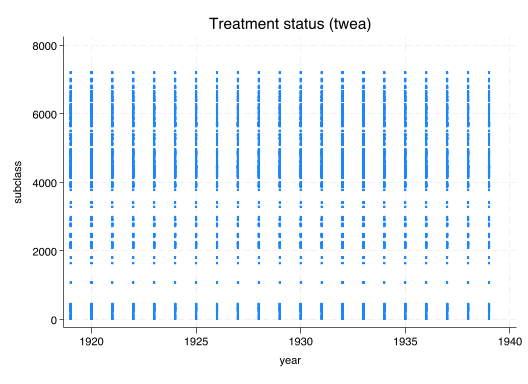

In [95]:

*Treatment plot

* Panel order 
sort subclass year
egen id = group(subclass)

* Indicator treated
gen treated = (twea>0)

* Year of adoption and order
bys id (year): egen first_treat = min(cond(treated==1, year, .))
replace first_treat = 9999 if missing(first_treat)
sort first_treat id year
egen id_rank = group(id)

* Plot treatment
twoway scatter id_rank year if treated==1, ///
    msymbol(square) msize(tiny) ///
    title("Treatment status (twea)") ///
    ytitle("subclass") xtitle("year") legend(off)


### 3.1 Static TWFE Regression

We estimate a model with fixed unit (`subclass`) and time (`year`) effects.
Standard errors are grouped at the `subclass` level.

In [17]:
* Static TWFE
xtreg patents twea i.year, fe i(subclass) cluster(subclass)

* Equivalent implementation with reghdfe
reghdfe patents twea, absorb(subclass year) cluster(subclass)


Fixed-effects (within) regression               Number of obs     =    289,920
Group variable: subclass                        Number of groups  =      7,248

R-squared:                                      Obs per group:
     Within  = 0.0480                                         min =         40
     Between = 0.0000                                         avg =       40.0
     Overall = 0.0255                                         max =         40

                                                F(40, 7247)       =      53.95
corr(u_i, Xb) = -0.0059                         Prob > F          =     0.0000

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        twea |   .2882615   

### 3.2 Equivalence between TWFE and canonical DiD

In this case, the coefficient of `twea` coincides with the classical DiD estimator.

In [18]:
* Canonical DiD
reg patents treatmentgroup post twea, cluster(subclass)


Linear regression                               Number of obs     =    289,920
                                                F(3, 7247)        =     445.38
                                                Prob > F          =     0.0000
                                                R-squared         =     0.0138
                                                Root MSE          =      1.345

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
treatmentg~p |  -.1780874   .0338152    -5.27   0.000    -.2443751   -.1117996
        post |   .2996666   .0090614    33.07   0.000     .2819036    .3174296
        twea |   .2882615   .0388846     7.41   0.000     .2120364    .3644867
       _cons |

### 3.3 Treatment Randomization Test

This test assesses whether the treatment and control groups differ before treatment.

In [19]:
* Pre-treatment period only
* Regress patents on the treatment group indicator
* using only pre-treatment years (before 1919).
reg patents treatmentgroup if year<=1918, cluster(subclass)


Linear regression                               Number of obs     =    137,712
                                                F(1, 7247)        =      27.74
                                                Prob > F          =     0.0000
                                                R-squared         =     0.0012
                                                Root MSE          =     1.0874

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
treatmentg~p |  -.1780874   .0338152    -5.27   0.000     -.244375   -.1117997
       _cons |   .3143656   .0098186    32.02   0.000     .2951183    .3336128
------------------------------------------------------------------------------


### 3.4 Event-study TWFE

Dynamic effects are estimated using leads and lags. The key test is that the pre-treatment coefficients are jointly zero.

In [20]:
* Event-study TWFE
reg patents i.year treatmentgroup reltimeminus* reltimeplus*, cluster(subclass)

* Joint pre-tendency test
test reltimeminus1 reltimeminus2 reltimeminus3 reltimeminus4 reltimeminus5 /// 
reltimeminus6 reltimeminus7 reltimeminus8 reltimeminus9 reltimeminus10 /// 
reltimeminus11 reltimeminus12 reltimeminus13 reltimeminus14 /// 
reltimeminus15 reltimeminus16 reltimeminus17 reltimeminus18


Linear regression                               Number of obs     =    289,920
                                                F(79, 7247)       =      31.36
                                                Prob > F          =     0.0000
                                                R-squared         =     0.0272
                                                Root MSE          =     1.3361

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        year |
       1901  |    .005787   .0080773     0.72   0.474    -.0100469     .021621
       1902  |   .0065104   .0087528     0.74   0.457    -.0106477    .0236685
       1903  |   .0339988   .0091394     3.72   0.000     .0160829    .0519147

The event-study graph is constructed from the estimated coefficients and their confidence intervals.

(Note: Below code run with echo to enable preserve/restore functionality.)



Linear regression                               Number of obs     =    289,920
                                                F(79, 7247)       =      31.36
                                                Prob > F          =     0.0000
                                                R-squared         =     0.0272
                                                Root MSE          =     1.3361

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
reltimemi~s1 |  -.0270337    .044596    -0.61   0.544    -.1144549    .0603875
reltimemi~s2 |  -.0963748   .0367189    -2.62   0.009    -.1683545   -.0243952
reltimemi~s3 |  

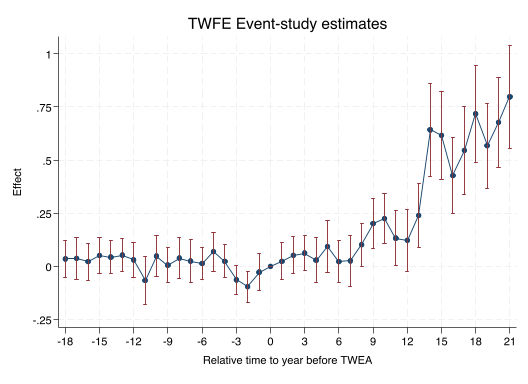

In [21]:
* Generating corresponding ES plot
{
/* We produce the E-S graph by creating a matrix (res) gathering the time to the 
event, the point estimates and the CI */

reg patents reltimeminus* reltimeplus* i.year treatmentgroup, cluster(subclass)

matrix temp=r(table)'
matrix res=J(40,4,0)
matrix res[19,1]=0
forvalues x = 1/18 {
matrix res[19-`x',1]=-`x'
matrix res[19-`x',2]=temp[`x',1]
matrix res[19-`x',3]=temp[`x',5]
matrix res[19-`x',4]=temp[`x',6]
}
forvalues x = 1/21 {
matrix res[`x'+19,1]=`x'
matrix res[`x'+19,2]=temp[`x'+18,1]
matrix res[`x'+19,3]=temp[`x'+18,5]
matrix res[`x'+19,4]=temp[`x'+18,6]
}

// Store sub matrix for the figure with the Borusyak et al estimator
matrix res_post=res["r19".."r40","c1".."c4"]

preserve
drop _all
svmat res
twoway (scatter res2 res1, msize(medlarge) msymbol(o) mcolor(navy) legend(off)) ///
	(line res2 res1, lcolor(navy)) (rcap res4 res3 res1, lcolor(maroon)), ///
	 title("TWFE Event-study estimates") xtitle("Relative time to year before TWEA") ///
	 ytitle("Effect") xlabel(-18(3)21) yscale(range(-0.25 1)) ylabel(-0.25(.25)1)
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser1.pdf", replace
restore
}

In [22]:
* Verifying "by hand" that event-study coefficients are simple DIDs

sum patents if year==1919&treatmentgroup==1
scalar m1=r(mean)
sum patents if year==1918&treatmentgroup==1
scalar m2=r(mean)
sum patents if year==1919&treatmentgroup==0
scalar m3=r(mean)
sum patents if year==1918&treatmentgroup==0
scalar m4=r(mean)
di m1-m2-(m3-m4)


    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     patents |        336    .2380952    .7589317          0          7

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     patents |        336     .235119    1.057208          0         15

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     patents |      6,912    .4053819    1.253219          0         27

    Variable |        Obs        Mean    Std. dev.       Min        Max
-------------+---------------------------------------------------------
     patents |      6,912    .4259259    1.486547          0         43
.02352017


### 3.5 Event-study without pre-treatment periods

The model is re-estimated excluding the leads, allowing for comparison with the dynamic DiD in the post-treatment period.

In [23]:

* Event-study specification excluding pre-treatment leads.
* Used to verify equation (3.7) for ℓ = 1 by computing the DID on the RHS.
reg patents i.yearpost treatmentgroup reltimeplus*, cluster(subclass)


Linear regression                               Number of obs     =    289,920
                                                F(43, 7247)       =      44.44
                                                Prob > F          =     0.0000
                                                R-squared         =     0.0256
                                                Root MSE          =     1.3371

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
    yearpost |
       1919  |   .0910164    .010257     8.87   0.000     .0709097    .1111231
       1920  |   .0833486   .0112046     7.44   0.000     .0613842    .1053129
       1921  |   .1293555   .0120567    10.73   0.000     .1057208    .1529902

(Note: Below code run with echo to enable preserve/restore functionality.)



Linear regression                               Number of obs     =    289,920
                                                F(43, 7247)       =      44.44
                                                Prob > F          =     0.0000
                                                R-squared         =     0.0256
                                                Root MSE          =     1.3371

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
reltimeplus1 |   .0108007   .0309763     0.35   0.727     -.049922    .0715233
reltimeplus2 |   .0393018   .0302047     1.30   0.193    -.0199081    .0985118
reltimeplus3 |  

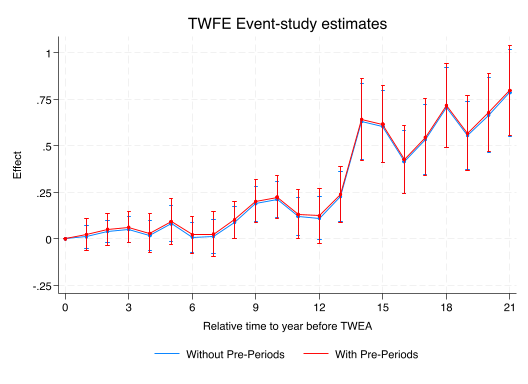

In [24]:
* Generating corresponding ES plot
{
reg patents reltimeplus* i.yearpost treatmentgroup, cluster(subclass)

matrix temp=r(table)'
matrix res=J(22,4,0)
matrix res[1,1]=0
forvalues x = 1/21 {
matrix res[`x'+1,1]=`x'
matrix res[`x'+1,2]=temp[`x',1]
matrix res[`x'+1,3]=temp[`x',5]
matrix res[`x'+1,4]=temp[`x',6]
}

preserve
drop _all
svmat res
svmat res_post
twoway (scatter res2 res1, msize(small) msymbol(o) mcolor(midblue) legend(order(2 /*"  &" 3*/ "Without Pre-Periods" 4 /*"  &" 5*/ "With Pre-Periods") pos(6) col(2))) ///
	(line res2 res1, lcolor(midblue)) (rcap res4 res3 res1, lcolor(midblue)) ///
	(line res_post2 res1, lcolor(red)) (rcap res_post4 res_post3 res1, lcolor(red)) ///
	(scatter res_post2 res1, msize(small) msymbol(o) mcolor(red)), ///
	 title("TWFE Event-study estimates") xtitle("Relative time to year before TWEA") ///
	 ytitle("Effect") xlabel(0(3)21) yscale(range(-0.25 1)) ylabel(-0.25(.25)1)
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser2.pdf", replace
restore
}

In [25]:
*Numerically equivalent to Borusyak et al, Gardner, Liu et al

gen cohort=1919 if treatmentgroup==1

did_imputation patents subclass year cohort, horizons(0/20) autosample minn(0)


*Numerically equivalent to having all year FEs in the regression

reg patents i.year treatmentgroup reltimeplus*, cluster(subclass)


(276,480 missing values generated)

                                                       Number of obs = 289,920
------------------------------------------------------------------------------
     patents | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
        tau0 |   .0108007   .0309719     0.35   0.727    -.0499032    .0715045
        tau1 |   .0393018   .0302004     1.30   0.193    -.0198898    .0984934
        tau2 |   .0498425   .0359675     1.39   0.166    -.0206525    .1203374
        tau3 |   .0166497   .0418039     0.40   0.690    -.0652844    .0985838
        tau4 |   .0803071   .0495399     1.62   0.105    -.0167894    .1774036
        tau5 |   .0089819   .0410491     0.22   0.827    -.0714729    .0894366
        tau6 |   .0129501   .0472565     0.27   0.784     -.079671    .1055712
        tau7 |   .0885536    .043196     2.05   0.040     .0038911    .1732162
        tau8 |  

### 3.6 Undetected Linear Pretrends

This section assesses whether the results could be explained by differential linear trends not detected by standard tests.

In [26]:
local github https://raw.githubusercontent.com
net install pretrends, from(`github'/mcaceresb/stata-pretrends/main) replace

reghdfe patents reltimeminus* reltimeplus*, absorb(treatmentgroup year) cluster(subclass)
pretrends power 0.5, numpre(6)

checking pretrends consistency and verifying not already installed...
all files already exist and are up to date.
(MWFE estimator converged in 2 iterations)

HDFE Linear regression                            Number of obs   =    289,920
Absorbing 2 HDFE groups                           F(  39,   7247) =       5.37
Statistics robust to heteroskedasticity           Prob > F        =     0.0000
                                                  R-squared       =     0.0272
                                                  Adj R-squared   =     0.0270
                                                  Within R-sq.    =     0.0015
Number of clusters (subclass) =      7,248        Root MSE        =     1.3361

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+-

(Note: Below code run with echo to enable preserve/restore functionality.)


(86,976 observations deleted)

Linear regression                               Number of obs     =    202,944
                                                F(55, 7247)       =      33.81
                                                Prob > F          =     0.0000
                                                R-squared         =     0.0189
                                                Root MSE          =     1.4895

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
reltimemin~1 |  -.0270337    .044596    -0.61   0.544    -.1144549    .0603874
reltimemin~2 |  -.0963748   .0367188    -2.62   0.009    -.168354

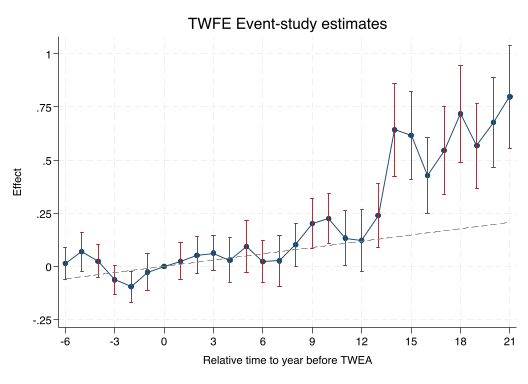

In [27]:
* Generating corresponding ES plot
{
local slope=r(slope)	
	
preserve
	
keep if year>=1912&year<=1939
drop reltimeminus7-reltimeminus18
	
reg patents reltimeminus* reltimeplus* i.year treatmentgroup, cluster(subclass)

restore 

matrix temp=r(table)'
matrix res=J(28,4,0)
matrix res[7,1]=0
forvalues x = 1/6 {
matrix res[7-`x',1]=-`x'
matrix res[7-`x',2]=temp[`x',1]
matrix res[7-`x',3]=temp[`x',5]
matrix res[7-`x',4]=temp[`x',6]
}
forvalues x = 1/21 {
matrix res[`x'+7,1]=`x'
matrix res[`x'+7,2]=temp[`x'+6,1]
matrix res[`x'+7,3]=temp[`x'+6,5]
matrix res[`x'+7,4]=temp[`x'+6,6]
}

preserve
drop _all
svmat res
twoway (scatter res2 res1, msize(medlarge) msymbol(o) mcolor(navy) legend(off)) ///
	(line res2 res1, lcolor(navy)) (rcap res4 res3 res1, lcolor(maroon)) (function y=x*`slope', range(-6 21) lcolor(gray) lpattern(dash)), ///
	 title("TWFE Event-study estimates") xtitle("Relative time to year before TWEA") ///
	 ytitle("Effect") xlabel(-6(3)21) yscale(range(-0.25 1)) ylabel(-0.25(.25)1)
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser3.pdf", replace
restore
}


### 3.7 Variance of the long-term effect

The variance of the results between groups is compared 14 years after treatment.

In [28]:
* Compare the variance of outcomes between treated and control subclasses
* 14 years after treatment (year = 1932).
sdtest diffpatentswrt1918 if year==1932, by(treatmentgroup)

* Difference in standard deviations between treated and control groups
di r(sd_2)-r(sd_1)
scalar sd_effects=r(sd_2)-r(sd_1)

* Point estimate of the treatment effect
reg diffpatentswrt1918 treatmentgroup if year==1932

* Confidence interval using the estimated variance difference
di _b[treatmentgroup]-1.96*sd_effects,_b[treatmentgroup]+1.96*sd_effects



Variance ratio test
------------------------------------------------------------------------------
   Group |     Obs        Mean    Std. err.   Std. dev.   [95% conf. interval]
---------+--------------------------------------------------------------------
       0 |   6,912    .3577836    .0213236    1.772807    .3159828    .3995843
       1 |     336           1    .1097584    2.011905    .7840975    1.215903
---------+--------------------------------------------------------------------
Combined |   7,248    .3875552    .0210201    1.789547    .3463497    .4287606
------------------------------------------------------------------------------
    ratio = sd(0) / sd(1)                                         f =   0.7764
H0: ratio = 1                                   Degrees of freedom = 6911, 335

    Ha: ratio < 1               Ha: ratio != 1                 Ha: ratio > 1
  Pr(F < f) = 0.0004         2*Pr(F < f) = 0.0008           Pr(F > f) = 0.9996
.23909779

      Source |       

### 3.8 Placebo tests

Placebo tests are performed to assess spurious heterogeneity before treatment.

In [29]:
*** Treatment effect heterogeneity (14 years)
* Variance test 14 years after treatment.
* H0: v14 = 0 (no heterogeneity).
sdtest diffpatentswrt1918 if year==1904, by(treatmentgroup)

*** Placebo tests (pre-treatment)
forvalue i=1900/1939{
sdtest diffpatentswrt1918 if year==`i', by(treatmentgroup)
}



Variance ratio test
------------------------------------------------------------------------------
   Group |     Obs        Mean    Std. err.   Std. dev.   [95% conf. interval]
---------+--------------------------------------------------------------------
       0 |   6,912   -.1860532     .016412    1.364469   -.2182258   -.1538807
       1 |     336   -.1428571    .0368856    .6761234   -.2154136   -.0703007
---------+--------------------------------------------------------------------
Combined |   7,248   -.1840508    .0157444      1.3404   -.2149143   -.1531872
------------------------------------------------------------------------------
    ratio = sd(0) / sd(1)                                         f =   4.0726
H0: ratio = 1                                   Degrees of freedom = 6911, 335

    Ha: ratio < 1               Ha: ratio != 1                 Ha: ratio > 1
  Pr(F < f) = 1.0000         2*Pr(F > f) = 0.0000           Pr(F > f) = 0.0000

Variance ratio test
-----------

## Chapter 4 — Extensions to the Basic DiD Model

This chapter extends the basic DiD estimators to address:

- baseline covariate control,
- interactive fixed effects,
- synthetic control methods,
- sensitivity analysis to pretrend violations.

### 4.1 Estimators with Controls

The initial level of patents (`patents1900`) is controlled, allowing its effect to vary over time.

In [30]:
* TWFE with patent control in 1900
reghdfe patents reltimeminus* reltimeplus*, /// 
absorb(year#patents1900 treatmentgroup) cluster(subclass)

* Joint pre-tendency test
test reltimeminus1 reltimeminus2 reltimeminus3 reltimeminus4 reltimeminus5 /// 
reltimeminus6 reltimeminus7 reltimeminus8 reltimeminus9 reltimeminus10 /// 
reltimeminus11 reltimeminus12 reltimeminus13 reltimeminus14 /// 
reltimeminus15 reltimeminus16 reltimeminus17 reltimeminus18

(dropped 120 singleton observations)
(MWFE estimator converged in 3 iterations)

HDFE Linear regression                            Number of obs   =    289,800
Absorbing 2 HDFE groups                           F(  39,   7244) =       5.67
Statistics robust to heteroskedasticity           Prob > F        =     0.0000
                                                  R-squared       =     0.2017
                                                  Adj R-squared   =     0.2005
                                                  Within R-sq.    =     0.0018
Number of clusters (subclass) =      7,245        Root MSE        =     1.2046

                           (Std. err. adjusted for 7,245 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
reltimemi~s1 

The event-study corresponding to the model with controls is built.

(Note: Below code run with echo to enable preserve/restore functionality.)


(dropped 120 singleton observations)
(MWFE estimator converged in 3 iterations)

HDFE Linear regression                            Number of obs   =    289,800
Absorbing 2 HDFE groups                           F(  39,   7244) =       5.67
Statistics robust to heteroskedasticity           Prob > F        =     0.0000
                                                  R-squared       =     0.2017
                                                  Adj R-squared   =     0.2005
                                                  Within R-sq.    =     0.0018
Number of clusters (subclass) =      7,245        Root MSE        =     1.2046

                           (Std. err. adjusted for 7,245 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+-

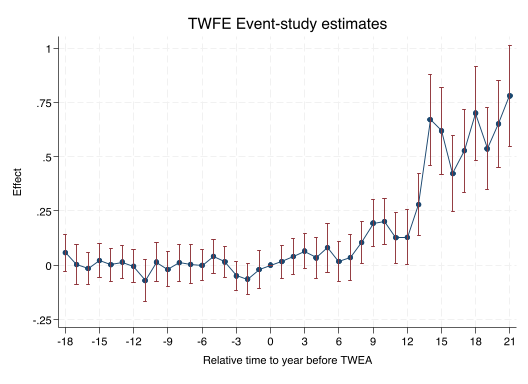

In [31]:
*** Event-study plot with controls
*Producing the graph
reghdfe patents reltimeminus* reltimeplus*, absorb(year#patents1900 treatmentgroup) cluster(subclass)
matrix temp=r(table)'
matrix res=J(40,4,0)
matrix res[19,1]=0
forvalues x = 1/18 {
matrix res[19-`x',1]=-`x'
matrix res[19-`x',2]=temp[`x',1]
matrix res[19-`x',3]=temp[`x',5]
matrix res[19-`x',4]=temp[`x',6]
}
forvalues x = 1/21 {
matrix res[`x'+19,1]=`x'
matrix res[`x'+19,2]=temp[`x'+18,1]
matrix res[`x'+19,3]=temp[`x'+18,5]
matrix res[`x'+19,4]=temp[`x'+18,6]
}

preserve
drop _all
svmat res
twoway (scatter res2 res1, msize(medlarge) msymbol(o) mcolor(navy) legend(off)) ///
	(line res2 res1, lcolor(navy)) (rcap res4 res3 res1, lcolor(maroon)), ///
	 title("TWFE Event-study estimates") xtitle("Relative time to year before TWEA") ///
	 ytitle("Effect") xlabel(-18(3)21) yscale(range(-0.25 1)) ylabel(-0.25(.25)1)
	 
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser_controls.pdf", replace
restore


It is verified whether the baseline covariate is correlated with the treated group.

In [32]:
*Testing that treatment group indicator and covariate are correlated
reg patents1900 treatmentgroup if year==1900


      Source |       SS           df       MS      Number of obs   =     7,248
-------------+----------------------------------   F(1, 7246)      =     13.05
       Model |  7.82905752         1  7.82905752   Prob > F        =    0.0003
    Residual |  4345.55822     7,246   .59971822   R-squared       =    0.0018
-------------+----------------------------------   Adj R-squared   =    0.0017
       Total |  4353.38728     7,247  .600715783   Root MSE        =    .77441

------------------------------------------------------------------------------
 patents1900 | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
treatmentg~p |   -.156312   .0432625    -3.61   0.000     -.241119    -.071505
       _cons |   .2217882   .0093148    23.81   0.000     .2035285    .2400478
------------------------------------------------------------------------------


A dynamic DiD is estimated by non-parametrically controlling for the initial covariate.



-------------------------------------------------------------------------------
> -
             Estimation of treatment effects: Event-study effects
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI          N 
-------------+-------------------------------------------------------
    Effect_1 |  .0123774     .04079  -.0675695   .0923242       6992 
    Effect_2 |    .03685   .0429563  -.0473428   .1210428       6992 
    Effect_3 |  .0617362   .0424486  -.0214616    .144934       6992 
    Effect_4 |  .0265509   .0510521  -.0735094   .1266112       6992 
    Effect_5 |  .0733544   .0612449  -.0466835   .1933922       6992 
    Effect_6 |  .0122893   .0489294  -.0836105   .1081892       6992 
    Effect_7 |  .0279862   .0558801  -.0815369   .1375093       6992 
    Effect_8 |  .1010481   .0496669   .0037028   .1983933       6992 
    Effect_9 |  .1877217   .0571643   .0756817   .2997617      

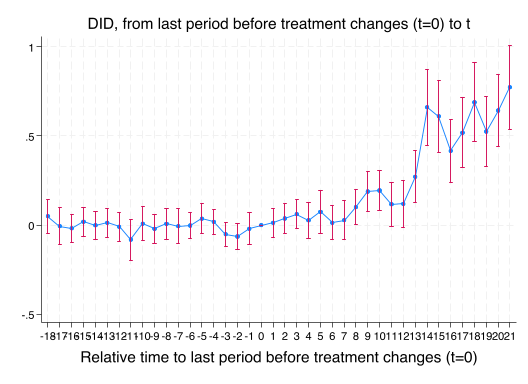

In [33]:
*Controlling for patents in 1900, DID (not on figure)
did_multiplegt_dyn patents subclass year twea, ///
    effects(21) placebo(18) trends_nonparam(patents1900)

### 4.2 Interactive Fixed Effects

Unobserved factors are allowed to vary over time with specific per-unit loads.

checking fect consistency and verifying not already installed...
all files already exist and are up to date.
checking _gwtmean consistency and verifying not already installed...
all files already exist and are up to date.
Balanced Panel Data
-------------------------------------------------------------------------------
Cross Validation...
fe r=0 force=two-way mspe=1.0384
ife r=1 force=two-way mspe=.9232
ife r=2 force=two-way mspe=.8733
ife r=3 force=two-way mspe=1.147
ife r=4 force=two-way mspe=1.3805
optimal r=2 in fe/ife model
Balanced Panel Data
-------------------------------------------------------------------------------
Cross Validation...
fe r=0 force=two-way mspe=.24
ife r=1 force=two-way mspe=.2341
ife r=2 force=two-way mspe=.241
ife r=3 force=two-way mspe=.2414
ife r=4 force=two-way mspe=.3176
optimal r=1 in fe/ife model
Balanced Panel Data
-------------------------------------------------------------------------------
Bootstrapping...
ATT Estimation: Already Bootstrapped 1

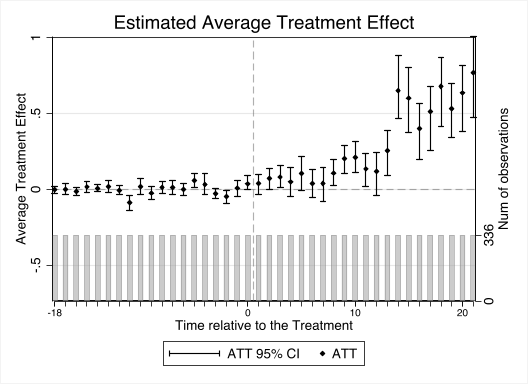

In [34]:
net install fect, from(https://raw.githubusercontent.com/xuyiqing/fect_stata/master/) replace
ssc install _gwtmean, replace

*Optimal number of factors = 2
fect patents, treat(twea) unit(subclass) time(year) method("ife") r(4) tol(1e-4) cv

*If cross-validation on the treated only, optimal number of factors =1
fect patents, treat(twea) unit(subclass) time(year) method("ife") r(4) cv tol(1e-4) cvtreat  

timer clear
timer on 1
set seed 1 
fect patents, treat(twea) unit(subclass) time(year) method("ife") r(2) tol(1e-4) se
timer off 1
timer list
matrix list e(ATT)

The dynamic effects estimated by IFE are compared with those obtained under TWFE.

(Note: Below code run with echo to enable preserve/restore functionality.)







number of observations will be reset to 21
Press any key to continue, or Break to abort
Number of observations (_N) was 0, now 21.



file
    /Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser_ife_did.pd
    > f saved as PDF format





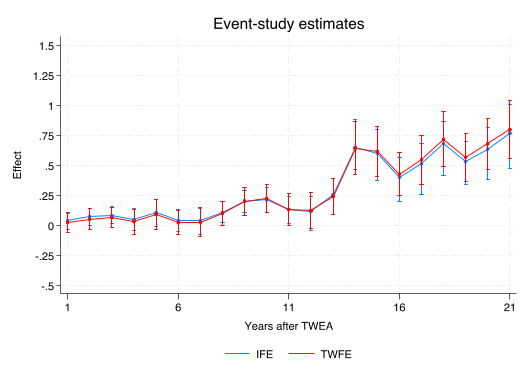

In [35]:
*Run time on Dell desktop computer, processor 11th Gen Intel(R) Core(TM) i7-11700T @ 1.40GHz 1.39 GHz, Stata MP 18: 554 seconds. 
matrix res_ife=J(21,4,0)
forvalues x = 1/21 {
matrix res_ife[`x',1]=`x'
matrix res_ife[`x',2]=e(ATTs)[`x'+19,3]
matrix res_ife[`x',3]=e(ATTs)[`x'+19,6]
matrix res_ife[`x',4]=e(ATTs)[`x'+19,7]
}

matrix res_post=res_post[2..22,1..4]

preserve
drop _all
svmat res_ife
svmat res_post
twoway (scatter res_ife2 res_ife1, msize(small) msymbol(o) mcolor(midblue) legend(order(2 /*"  &" 3*/ "IFE" 4 /*"  &" 5*/ "TWFE") pos(6) col(2))) ///
	(line res_ife2 res_ife1, lcolor(midblue)) (rcap res_ife4 res_ife3 res_ife1, lcolor(midblue)) ///
	(line res_post2 res_post1, lcolor(red)) (rcap res_post4 res_post3 res_post1, lcolor(red)) ///
	(scatter res_post2 res_post1, msize(small) msymbol(o) mcolor(red)), ///
	 title("Event-study estimates") xtitle("Years after TWEA") ///
	 ytitle("Effect") xscale(range(1 21)) xlabel(1(5)21) yscale(range(-0.5 1.5)) ylabel(-0.5(.25)1.5)
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser_ife_did.pdf", replace
restore


### 4.3 Synthetic Control

Dynamic effects are estimated using synthetic control, with bootstrap-based inference.

In [36]:
* Estimate dynamic treatment effects using synthetic control.
* Standard errors obtained via bootstrap.

ssc install sdid_event, replace

timer clear
timer on 1
set seed 1 
sdid_event patents subclass year twea, method("sc") brep(200)
timer off 1
timer list

checking sdid_event consistency and verifying not already installed...
all files already exist and are up to date.
Synthetic Control

Boostrap replications (200), bootstrap mode.
|0% ----------------------------------------- 100%|
|.................................................|


             |  Estimate         SE      LB CI      UB CI  Switchers 
-------------+------------------------------------------------------
         ATT |  .4143695   .0990729   .2201867   .6085523        336 
    Effect_1 |  .0847212   .0549971  -.0230731   .1925156        336 
    Effect_2 | -.8503927   .4822928  -1.795687   .0949012        336 
    Effect_3 |  .1855106   .0587349   .0703901   .3006311        336 
    Effect_4 |  .1453368   .0683699   .0113318   .2793417        336 
    Effect_5 |  .1580178   .0652356   .0301559   .2858796        336 
    Effect_6 |  .1628774   .0619782   .0414001   .2843546        336 
    Effect_7 |  .2300545    .071573   .0897714   .3703376        336 
    Effect_8 |  

(Note: Below code run with echo to enable preserve/restore functionality.)






number of observations will be reset to 21
Press any key to continue, or Break to abort
Number of observations (_N) was 0, now 21.



file
    /Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser_sc_did.pdf
    saved as PDF format





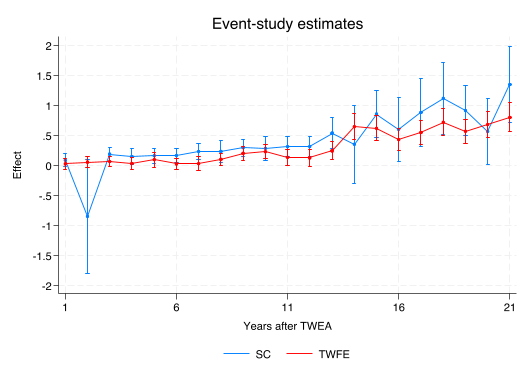

In [37]:
matrix res_sc=J(21,4,0)
forvalues x = 1/21 {
matrix res_sc[`x',1]=`x'
matrix res_sc[`x',2]=e(H)[`x'+1,1]
matrix res_sc[`x',3]=e(H)[`x'+1,3]
matrix res_sc[`x',4]=e(H)[`x'+1,4]
}

preserve
drop _all
svmat res_sc
svmat res_post
twoway (scatter res_sc2 res_sc1, msize(small) msymbol(o) mcolor(midblue) legend(order(2 /*"  &" 3*/ "SC" 4 /*"  &" 5*/ "TWFE") pos(6) col(2))) ///
	(line res_sc2 res_sc1, lcolor(midblue)) (rcap res_sc4 res_sc3 res_sc1, lcolor(midblue)) ///
	(line res_post2 res_post1, lcolor(red)) (rcap res_post4 res_post3 res_post1, lcolor(red)) ///
	(scatter res_post2 res_post1, msize(small) msymbol(o) mcolor(red)), ///
	 title("Event-study estimates") xtitle("Years after TWEA") ///
	 ytitle("Effect") xscale(range(1 21)) xlabel(1(5)21) yscale(range(-2 2)) ylabel(-2(.5)2)
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser_sc_did.pdf", replace
restore

The exercise is repeated after removing the pre-treatment average per unit.

(Note: Below code run with echo to enable preserve/restore functionality.)


(152,208 missing values generated)






Synthetic Control

Boostrap replications (200), bootstrap mode.
|0% ----------------------------------------- 100%|
|.................................................|


             |  Estimate         SE      LB CI      UB CI  Switchers 
-------------+------------------------------------------------------
         ATT |  .4742627   .2958464  -.1055961   1.054122        336 
    Effect_1 |  .1563171   .3195719  -.4700439   .7826781        336 
    Effect_2 |  .0574685    .347471  -.6235746   .7385116        336 
    Effect_3 |  -.203884   .4748395  -1.134569   .7268014        336 
    Effect_4 |  .1263265   .4188353  -.6945908   .9472437        336 
    Effect_5 |  .4512675   .3328846  -.2011863   1.103721        336 
    Effect_6 |  .2871878   .4233125  -.5425048    1.11688        336 
    Effect_7 | -.6302814   .4482395  -1.508831    .248268        336 
    Effect_8 

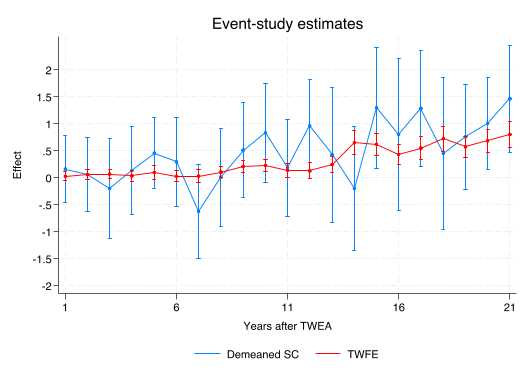

In [38]:
*Demeaned
bys subclass: egen pre_mean_temp=mean(patents) if year<=1918
bys subclass: egen pre_mean=mean(pre_mean_temp)
gen patents_demeaned=patents-pre_mean
timer clear
timer on 1
set seed 1 
sdid_event patents_demeaned subclass year twea, method("sc") brep(200)
timer off 1
timer list

matrix res_sc=J(21,4,0)
forvalues x = 1/21 {
matrix res_sc[`x',1]=`x'
matrix res_sc[`x',2]=e(H)[`x'+1,1]
matrix res_sc[`x',3]=e(H)[`x'+1,3]
matrix res_sc[`x',4]=e(H)[`x'+1,4]
}

preserve
drop _all
svmat res_sc
svmat res_post
twoway (scatter res_sc2 res_sc1, msize(small) msymbol(o) mcolor(midblue) legend(order(2 /*"  &" 3*/ "Demeaned SC" 4 /*"  &" 5*/ "TWFE") pos(6) col(2))) ///
	(line res_sc2 res_sc1, lcolor(midblue)) (rcap res_sc4 res_sc3 res_sc1, lcolor(midblue)) ///
	(line res_post2 res_post1, lcolor(red)) (rcap res_post4 res_post3 res_post1, lcolor(red)) ///
	(scatter res_post2 res_post1, msize(small) msymbol(o) mcolor(red)), ///
	 title("Event-study estimates") xtitle("Years after TWEA") ///
	 ytitle("Effect") xscale(range(1 21)) xlabel(1(5)21) yscale(range(-2 2)) ylabel(-2(.5)2)
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser_demeaned_sc_did.pdf", replace
restore


### 4.4 Synthetic DiD

DiD and synthetic control are combined into a single estimator.

(Note: Below code run with echo to enable preserve/restore functionality.)





Synthetic Difference-in-differences

Boostrap replications (200), bootstrap mode.
|0% ----------------------------------------- 100%|
|.................................................|


             |  Estimate         SE      LB CI      UB CI  Switchers 
-------------+------------------------------------------------------
         ATT |  .3019373   .0434581   .2167593   .3871152        336 
    Effect_1 |  .0300933   .0359936  -.0404541   .1006407        336 
    Effect_2 |   .049484   .0346309  -.0183926   .1173605        336 
    Effect_3 |  .0707202   .0377632  -.0032956    .144736        336 
    Effect_4 |  .0399446   .0457867  -.0497973   .1296865        336 
    Effect_5 |  .0926634    .054679  -.0145075   .1998343        336 
    Effect_6 |  .0282965   .0399082  -.0499237   .1065167        336 
    Effect_7 |  .0274996   .0491559  -.0688459   .1238451        336 
    Effect_8 |  .0982746   .04491

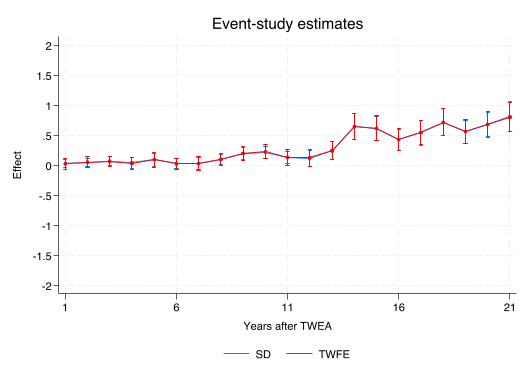

In [39]:
timer clear
timer on 1
set seed 1 
sdid_event patents subclass year twea, brep(200)
timer off 1
timer list

matrix res_sd=J(21,4,0)
forvalues x = 1/21 {
matrix res_sd[`x',1]=`x'
matrix res_sd[`x',2]=e(H)[`x'+1,1]
matrix res_sd[`x',3]=e(H)[`x'+1,3]
matrix res_sd[`x',4]=e(H)[`x'+1,4]
}

preserve
drop _all
svmat res_sd
svmat res_post
twoway (scatter res_sd2 res_sd1, msize(small) msymbol(o) mcolor(midblue) legend(order(2 /*"  &" 3*/ "SD" 4 /*"  &" 5*/ "TWFE") pos(6) col(2))) ///
	(line res_sd2 res_sd1, lcolor(midblue)) (rcap res_sd4 res_sd3 res_sd1, lcolor(midblue)) ///
	(line res_post2 res_post1, lcolor(red)) (rcap res_post4 res_post3 res_post1, lcolor(red)) ///
	(scatter res_post2 res_post1, msize(small) msymbol(o) mcolor(red)), ///
	 title("Event-study estimates") xtitle("Years after TWEA") ///
	 ytitle("Effect") xscale(range(1 21)) xlabel(1(5)21) yscale(range(-2 2)) ylabel(-2(.5)2)
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphES_moser_sd_did.pdf", replace
restore



### 4.5 Sensitivity Analysis (Rambachan and Roth)

The robustness of the estimated effects is evaluated in the face of potential violations of pre-trends.

checking honestdid consistency and verifying not already installed...
all files already exist and are up to date.
checking coefplot consistency and verifying not already installed...
all files already exist and are up to date.
(MWFE estimator converged in 2 iterations)

HDFE Linear regression                            Number of obs   =    289,920
Absorbing 2 HDFE groups                           F(  39,   7247) =       5.37
Statistics robust to heteroskedasticity           Prob > F        =     0.0000
                                                  R-squared       =     0.0272
                                                  Adj R-squared   =     0.0270
                                                  Within R-sq.    =     0.0015
Number of clusters (subclass) =      7,248        Root MSE        =     1.3361

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |   

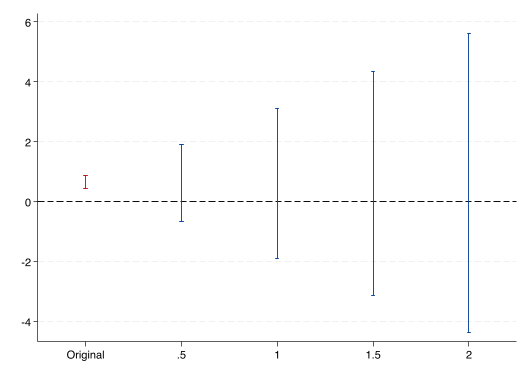

In [40]:
ssc install honestdid
ssc install coefplot, replace

reghdfe patents reltimeminus* reltimeplus*, absorb(year treatmentgroup) cluster(subclass)
matrix l_vec = J(21,1,0)
matrix l_vec[14,1]=1
honestdid, pre(1/18) post(19/39) mvec(0.5(0.5)2) l_vec(l_vec) coefplot
honestdid, pre(1/3) post(19) mvec(0.5(0.5)2)
honestdid, pre(1/7) post(19) mvec(0.5(0.5)2)


Sensitivity using only a specific lead and lag.

(Note: Below code run with echo to enable preserve/restore functionality.)



(268,176 observations deleted)

(MWFE estimator converged in 2 iterations)

HDFE Linear regression                            Number of obs   =     21,744
Absorbing 2 HDFE groups                           F(   2,   7247) =      16.96
Statistics robust to heteroskedasticity           Prob > F        =     0.0000
                                                  R-squared       =     0.0277
                                                  Adj R-squared   =     0.0275
                                                  Within R-sq.    =     0.0018
Number of clusters (subclass) =      7,248        Root MSE        =     1.4584

                           (Std. err. adjusted for 7,248 clusters in subclass)
------------------------------------------------------------------------------
             |               Robust
     patents | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+-----

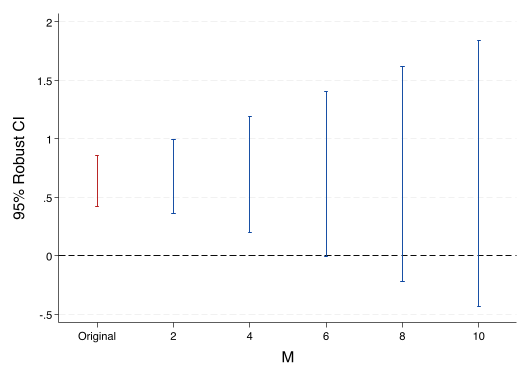

In [41]:
*** Rambachan & Roth (2023) sensitivity (honestdid) using β_fe,-1 and β_fe,1
preserve
keep if year==1918|year==1904|year==1932
reghdfe patents reltimeminus14 reltimeplus14 /// 
, absorb(year treatmentgroup) cluster(subclass)
honestdid, pre(1) post(2) mvec(2(2)10) coefplot xtitle(M, size(large)) ytitle(95% Robust CI, size(large))
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/coefplot.pdf", replace
restore


## Chapter 5 — TWFE and Weight Decomposition

This chapter examines how TWFE estimators combine comparisons between units and periods, using data from **Gentzkow et al. (2011)**.

Before we begin, we load the database corresponding to this chapter.

In [42]:
use "cc_xd_didtextbook_2025_9_30/Data sets/gentzkow et al 2011/gentzkowetal_didtextbook.dta", clear


### 5.1 TWFE Regression

A standard TWFE model is estimated and the estimator is decomposed into its implicit weights.

In [43]:
* TWFE estimation
areg prestout i.year numdailies, absorb(cnty90) cluster(cnty90)

* Weight decomposition
twowayfeweights prestout cnty90 year numdailies, type(feTR)


Linear regression, absorbing indicators             Number of obs     = 16,872
Absorbed variable: cnty90                           No. of categories =  1,195
                                                    F(16, 1194)       = 310.47
                                                    Prob > F          = 0.0000
                                                    R-squared         = 0.7006
                                                    Adj R-squared     = 0.6774
                                                    Root MSE          = 0.1255

                             (Std. err. adjusted for 1,195 clusters in cnty90)
------------------------------------------------------------------------------
             |               Robust
    prestout | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        year |
       1872  |  -.0117399   .0084998    -1.38   0.167    -.0284162    .0049364

### 5.2 TWFE with State-Specific Trends

Each state is allowed to have its own temporal trend, controlling for unobserved heterogeneity.

In [44]:
* Create trend dummies by state
qui tab styr, gen(styr)

* Estimation with specific trends
qui areg prestout i.year i.styr numdailies, absorb(cnty90) cluster(cnty90)
di _b[numdailies], _se[numdailies]

* Decomposition with controls
twowayfeweights prestout cnty90 year numdailies, ///
type(feTR) controls(styr1-styr683)

-.00121217 .0010962

Under the common trends assumption,
the TWFE coefficient beta, equal to -0.0012, estimates a weighted sum of 10342 
> ATTs. 
6195 ATTs receive a positive weight, and 4147 receive a negative weight.
10378 (g,t) cells receive the treatment, but the ATTs of 36 cells receive a wei
> ght equal to zero.
------------------------------------------------
Treat. var: numdailies  # ATTs      Σ weights  
------------------------------------------------
Positive weights        6195        1.5331      
Negative weights        4147        -0.5331     
------------------------------------------------
Total                   10342       1.0000      
------------------------------------------------


The development of this package was funded by the European Union (ERC, REALLYCR
> EDIBLE,GA N°101043899).


### 5.3 First Difference Regression

The model is estimated using first differences with specific trends, and the estimator weights are re-analyzed.

In [48]:
* First Difference Estimation
areg changeprestout changedailies, absorb(styr) cluster(cnty90)

*Decomposition
twowayfeweights changeprestout cnty90 year changedailies numdailies, type(fdTR) controls(styr1-styr683) 

*Assessing if weights correlated with year variable
twowayfeweights changeprestout cnty90 year changedailies numdailies, type(fdTR) controls(styr1-styr683) test_random_weights(year)




Linear regression, absorbing indicators             Number of obs     = 15,627
Absorbed variable: styr                             No. of categories =    634
                                                    F(1, 1194)        =   7.68
                                                    Prob > F          = 0.0057
                                                    R-squared         = 0.5690
                                                    Adj R-squared     = 0.5507
                                                    Root MSE          = 0.0816

                             (Std. err. adjusted for 1,195 clusters in cnty90)
------------------------------------------------------------------------------
             |               Robust
changepres~t | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
changedail~s |   .0025907   .0009351     2.77   0.006     .0007561    .0044252
       _cons |

## Chapter 6 — Multiple Cohorts and Alternative Estimators

This chapter analyzes data with **stepwise treatments** and compares different Difference-in-Differences estimators proposed in the recent literature.

Before starting, the database used in this chapter is loaded.

In [49]:
use "cc_xd_didtextbook_2025_9_30/Data sets/Wolfers 2006/wolfers2006_didtextbook.dta", clear

(Divorce data from Wolfers (2006) AER)


### 6.1 Static TWFE Regression

A standard TWFE model with fixed effects per state and year is estimated,
weighted by state population.

In [50]:
*Static TWFE
reg div_rate udl i.state i.year [w=stpop], vce(cluster state)

(analytic weights assumed)
(sum of wgt is 6,658,497,317)

Linear regression                               Number of obs     =      1,631
                                                F(32, 50)         =          .
                                                Prob > F          =          .
                                                R-squared         =     0.9305
                                                Root MSE          =     .52417

                                 (Std. err. adjusted for 51 clusters in state)
------------------------------------------------------------------------------
             |               Robust
    div_rate | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
         udl |  -.0548378   .1507695    -0.36   0.718    -.3576673    .2479917
             |
       state |
         AL  |   -.957982   .0537405   -17.83   0.000    -1.065923    -.850041
      

### 6.2 Decomposition of the TWFE estimator

The implicit weights of the TWFE estimator are analyzed and it is assessed whether they are correlated with the duration of exposure.

In [51]:
ssc install twowayfeweights
*help twowayfeweights
twowayfeweights div_rate state year udl, ///
    type(feTR) test_random_weights(exposurelength) weight(stpop)


checking twowayfeweights consistency and verifying not already installed...
all files already exist and are up to date.

Under the common trends assumption,
the TWFE coefficient beta, equal to -0.0548, estimates a weighted sum of 522 AT
> Ts. 
490 ATTs receive a positive weight, and 32 receive a negative weight.
------------------------------------------------
Treat. var: udl         # ATTs      Σ weights  
------------------------------------------------
Positive weights        490         1.0259      
Negative weights        32          -0.0259     
------------------------------------------------
Total                   522         1.0000      
------------------------------------------------

Regression of variables possibly correlated with the treatment effect on the we
> ights

B[1,4]
                     Coef           SE       t-stat  Correlation
exposurele~h   -8.2883613    .21360588    -38.80212   -.73253245


The development of this package was funded by the European Union (

### 6.3 Test of randomization in treatment timing

This assesses whether the timing of treatment initiation can be considered exogenous.

In [52]:
reg div_rate i.early_late_never if cohort!=1956 & year<=1968 ///
    [w=stpop], vce(cluster state)

(analytic weights assumed)
(sum of wgt is 2,247,966,000)

Linear regression                               Number of obs     =        611
                                                F(2, 47)          =       7.46
                                                Prob > F          =     0.0015
                                                R-squared         =     0.1707
                                                Root MSE          =     1.4824

                                 (Std. err. adjusted for 48 clusters in state)
------------------------------------------------------------------------------
             |               Robust
    div_rate | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
early_late~r |
          2  |  -.0457088   .4927483    -0.09   0.926     -1.03699    .9455728
          3  |  -1.363398   .3751166    -3.63   0.001    -2.118035    -.608761
             |
      

### 6.4 Event-study TWFE

Dynamic effects are estimated using an event-study TWFE and pre-trends are tested.

In [53]:
reg div_rate rel_time* i.state i.year [w=stpop], vce(cluster state)

* Joint pre-tendency test
test rel_timeminus1 rel_timeminus2 rel_timeminus3 rel_timeminus4 /// 
rel_timeminus5 rel_timeminus6 rel_timeminus7 rel_timeminus8 rel_timeminus9

(analytic weights assumed)
(sum of wgt is 6,658,497,317)

Linear regression                               Number of obs     =      1,631
                                                F(49, 50)         =          .
                                                Prob > F          =          .
                                                R-squared         =     0.9351
                                                Root MSE          =     .51043

                                 (Std. err. adjusted for 51 clusters in state)
------------------------------------------------------------------------------
             |               Robust
    div_rate | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
   rel_time1 |   .2891561   .2054259     1.41   0.165    -.1234539    .7017661
   rel_time2 |   .3358503   .1024966     3.28   0.002     .1299798    .5417208
   rel_time3 |   .3037197   .0958368

### 6.5 Decomposition of the First Dynamic Effect

The first coefficient of the event study is decomposed
to analyze which comparisons identify it.

In [54]:
twowayfeweights div_rate state year rel_time1, ///
    type(feTR) test_random_weights(year) weight(stpop) ///
    other_treatments(rel_time2-rel_time16) ///
    controls(rel_timeminus1-rel_timeminus9)



Under the common trends assumption,
the TWFE coefficient beta, equal to 0.2892, estimates the sum of several terms.

The first term is a weighted sum of 27 ATTs of the treatment.
27 ATTs receive a positive weight, and 0 receive a negative weight.
------------------------------------------------
Treat. var: rel_time1   # ATTs      Σ weights  
------------------------------------------------
Positive weights        27          1.0000      
Negative weights        0           0.0000      
------------------------------------------------
Total                   27          1.0000      
------------------------------------------------

The next term is a weighted sum of 29 ATTs of treatment 1 included in the other
> _treatments option.
16 ATTs receive a positive weight, and 13 receive a negative weight.
------------------------------------------------
Other treat.: rel_time2 # ATTs      Σ weights  
------------------------------------------------
Positive weights        16          0.0119 

### 6.6 Sun and Abraham (2021) Estimator

A robust event study is estimated for stepped treatments using adoption cohorts.

In [55]:
ssc install avar, replace
ssc install ivreg2, replace
*ssc install eventstudyinteract
*help eventstudyinteract
replace cohort=. if cohort==0
eventstudyinteract div_rate rel_time* [aweight=stpop], ///
	absorb(i.state i.year) cohort(cohort) control_cohort(controlgroup) ///
	vce(cluster state)


checking avar consistency and verifying not already installed...
all files already exist and are up to date.
checking ivreg2 consistency and verifying not already installed...
all files already exist and are up to date.
(660 real changes made, 660 to missing)
(sum of wgt is 3,493,823,905)
(obs=1,004)

IW estimates for dynamic effects                        Number of obs =  1,631
Absorbing 2 HDFE groups                                 F(240, 50)    =      .
                                                        Prob > F      =      .
                                                        R-squared     = 0.9414
                                                        Adj R-squared = 0.9270
                                                        Root MSE      = 0.5232
                                 (Std. err. adjusted for 51 clusters in state)
------------------------------------------------------------------------------
             |               Robust
    div_rate | Coefficient  s

### 6.7 Callaway and Sant’Anna (2021) Estimator

Dynamic average effects are estimated by cohort using untreated groups as controls.

In [56]:
*ssc install csdid
*help csdid
replace cohort=0 if cohort==.
csdid div_rate [weight=stpop], ivar(state) time(year) gvar(cohort) notyet agg(event)


(660 real changes made)
(importance weights assumed)
(importance weights assumed)
Units always treated found. These will be ignored
Panel is not balanced
Will use observations with Pair balanced (observed at t0 and t1)
..................................................
..................................................
..................................................
..................................................
..................................................
..................................................
....................
Difference-in-difference with Multiple Time Periods

                                                         Number of obs = 1,540
Outcome model  : regression adjustment
Treatment model: none
------------------------------------------------------------------------------
             | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
     Pre_avg |   .002322

### 6.8 Estimador de de Chaisemartin y D’Haultfoeuille

Se estiman efectos dinámicos permitiendo heterogeneidad entre cohortes y a lo largo del tiempo.



-------------------------------------------------------------------------------
> -
             Estimation of treatment effects: Event-study effects
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI          N 
-------------+-------------------------------------------------------
    Effect_1 |  .3009669   .0875908   .1292921   .4726416        320 
    Effect_2 |  .3035895    .072761   .1609806   .4461984        294 
    Effect_3 |  .2683828   .0758296   .1197596   .4170061        271 
    Effect_4 |  .1816435   .0848985   .0152454   .3480415        255 
    Effect_5 |  .1192688   .1007013  -.0781021   .3166398        220 
    Effect_6 |  .1148243   .1107215  -.1021858   .3318343        215 
    Effect_7 |  .1225242   .1306844  -.1336126    .378661        212 
    Effect_8 |  .0653645   .1164027  -.1627805   .2935095        209 
    Effect_9 | -.0758406   .1196254   -.310302   .1586208      

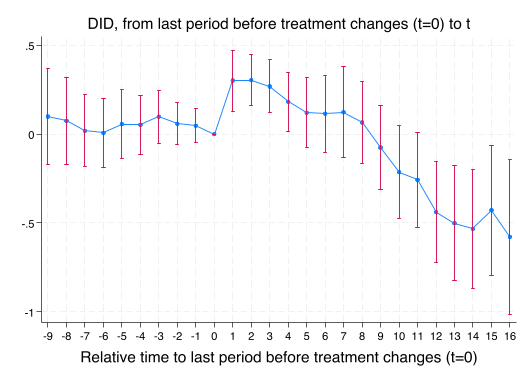

In [57]:
*ssc install did_multiplegt_dyn
*help did_imputation_dyn
did_multiplegt_dyn div_rate state year udl, ///
    effects(16) placebo(9) weight(stpop)


### 6.9 Estimador de Borusyak et al. (2021)

Se estima el efecto dinámico usando imputación bajo supuestos de tendencias paralelas.


In [58]:
*ssc install did_imputation
*help did_imputation
replace cohort = . if cohort==0

did_imputation div_rate state year cohort ///
    [aweight=stpop], horizons(0/15) autosample minn(0) pre(9)


(660 real changes made, 660 to missing)
> FE could not be imputed: tau0 tau1 tau2 tau3 tau4 tau5 tau6 tau7 tau8 tau9 ta
> u10 tau11 tau12 tau13 tau14 tau15.

                                                         Number of obs = 1,540
------------------------------------------------------------------------------
    div_rate | Coefficient  Std. err.      z    P>|z|     [95% conf. interval]
-------------+----------------------------------------------------------------
        tau0 |   .2649129   .1022424     2.59   0.010     .0645214    .4653044
        tau1 |   .3228116   .1076348     3.00   0.003     .1118512    .5337719
        tau2 |   .2508727   .1205181     2.08   0.037     .0146616    .4870837
        tau3 |   .1689476   .1318791     1.28   0.200    -.0895307    .4274259
        tau4 |   .1251728   .1440538     0.87   0.385    -.1571675     .407513
        tau5 |   .1701519   .1584173     1.07   0.283    -.1403404    .4806441
        tau6 |    .172082   .1682175     1.02   0.30

## Chapter 7 — Continuous Treatments and Robustness Tests

This chapter analyzes DiD estimators with continuous treatment (ntrgap) and studies various pre-trend and robustness tests, using data from Pierce and Schott (2016).


Before starting, the database corresponding to this chapter is loaded.

In [59]:
use "cc_xd_didtextbook_2025_9_30/Data sets/Pierce and Schott 2016/pierce_schott_didtextbook.dta", clear

### 7.1 TWFE Regressions

Simple TWFE regressions are estimated for different years, treating the NTR gap as a continuous treatment.

In [60]:

* TWFE regressions
reg delta2001 ntrgap, vce(hc2, dfadjust)
reg delta2002 ntrgap, vce(hc2, dfadjust)
reg delta2004 ntrgap, vce(hc2, dfadjust)
reg delta2005 ntrgap, vce(hc2, dfadjust)



Computing degrees of freedom ...

Linear regression                                       Number of obs =    103
                                                        F(1, 101)     =   2.32
                                                        Prob > F      = 0.1308
                                                        R-squared     = 0.0237
                                                        Adj R-squared = 0.0140
                                                        Root MSE      = 0.0543

------------------------------------------------------------------------------
             |             Robust HC2
   delta2001 | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      ntrgap |  -.0612112   .0401833    -1.52   0.136    -.1426751    .0202527
       _cons |  -.0141423   .0129623    -1.09   0.283    -.0404511    .0121665
---------------------------------------------------------

### 7.2 Weight Analysis

The implicit weights of the estimator are analyzed when the treatment is continuous.

In [61]:
*Weights analysis
twowayfeweights delta2001 indusid cons ntrgap ntrgap, type(fdTR)



Under the common trends assumption,
the TWFE coefficient beta, equal to -0.0612, estimates a weighted sum of 103 AT
> Ts. 
62 ATTs receive a positive weight, and 41 receive a negative weight.
------------------------------------------------
Treat. var: ntrgap      # ATTs      Σ weights  
------------------------------------------------
Positive weights        62          1.3190      
Negative weights        41          -0.3190     
------------------------------------------------
Total                   103         1.0000      
------------------------------------------------


The development of this package was funded by the European Union (ERC, REALLYCR
> EDIBLE,GA N°101043899).


### 7.3 Treatment Randomization Test

This test assesses whether the NTR gap is correlated with pre-treatment characteristics.

In [62]:
*Test that the NTR-gap treatment is as good as randomly assigned
reg ntrgap lemp1997 lemp1998 lemp1999 lemp2000, vce(hc2, dfadjust)



Computing degrees of freedom ...

Linear regression                                       Number of obs =    103
                                                        F(4, 98)      =   2.39
                                                        Prob > F      = 0.0560
                                                        R-squared     = 0.0775
                                                        Adj R-squared = 0.0398
                                                        Root MSE      = 0.1346

------------------------------------------------------------------------------
             |             Robust HC2
      ntrgap | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
    lemp1997 |  -.0219594   .1325814    -0.17   0.876    -.3877955    .3438767
    lemp1998 |   .6043265   .3103595     1.95   0.069    -.0534594    1.262112
    lemp1999 |  -.2260641   .4573776    -0.49   0.626    

### 7.4 Stute Test

The non-parametric Stute test is implemented to evaluate the validity of the DiD design.

In [63]:
stute_test delta2001 ntrgap, seed(1)
stute_test delta2002 ntrgap, seed(1)
stute_test delta2004 ntrgap, seed(1)
stute_test delta2005 ntrgap, seed(1)



(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0004426       .042 

(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0011319       .134 

(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0039215       .478 

(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0033582       .716 


A joint post-treatment effect test is performed.

In [64]:
preserve
    reshape long delta deltalintrend, i(indusid) j(year)
    stute_test delta ntrgap indusid year if year>=2001, seed(1)
restore


(Note: Below code run with echo to enable preserve/restore functionality.)



(j = 1997 1998 1999 2001 2002 2004 2005)
(variable deltalintrend1999 not found)

Data                               Wide   ->   Long
-----------------------------------------------------------------------------
Number of observations              103   ->   721         
Number of variables                  22   ->   12          
j variable (7 values)                     ->   year
xij variables:
      delta1997 delta1998 ... delta2005   ->   delta
deltalintrend1997 deltalintrend1998 ... deltalintrend2005->deltalintrend
-----------------------------------------------------------------------------


(Cramer-von Mises) Panel Stute Test

             |    t stat    p-value 
-------------+---------------------
        2001 |  .0004426       .042 
        2002 |  .0011319       .134 
        2004 |  .0039215       .478 
        2005 |  .0033582       .716 

Joint Stute test: 0.0089 (0.5400)
p-value in parenthesis.



Se evalúa la presencia de *quasi-stayers* en la intensidad del tratamiento.


In [65]:
*Test that quasi stayers
sort ntrgap
scalar stat_test_qs = ntrgap[1] / (ntrgap[2] - ntrgap[1])
di stat_test_qs


6.1498877


### 7.5 Pre-trend (linear) tests

Differences in trends are evaluated before treatment.


In [66]:
*Pre-trends test: linear
reg delta1999 ntrgap, vce(hc2, dfadjust)
reg delta1998 ntrgap, vce(hc2, dfadjust)
reg delta1997 ntrgap, vce(hc2, dfadjust)



Computing degrees of freedom ...

Linear regression                                       Number of obs =    103
                                                        F(1, 101)     =   4.31
                                                        Prob > F      = 0.0403
                                                        R-squared     = 0.0325
                                                        Adj R-squared = 0.0229
                                                        Root MSE      = 0.0437

------------------------------------------------------------------------------
             |             Robust HC2
   delta1999 | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      ntrgap |   .0580708   .0279591     2.08   0.045      .001389    .1147525
       _cons |  -.0051607   .0086782    -0.59   0.556    -.0227743    .0124529
---------------------------------------------------------

### 7.6 Pre-trends with industry-specific trends

Industry-specific linear trends are permitted, both in parametric and non-parametric form.

In [67]:
* Pre-trends test, with industry-specific linear trends: linear
reg deltalintrend1998 ntrgap, vce(hc2, dfadjust)
reg deltalintrend1997 ntrgap, vce(hc2, dfadjust)

* Pre-trends test, with industry-specific linear trends: non-parametric
stute_test deltalintrend1998 ntrgap, order(0) seed(1)
stute_test deltalintrend1997 ntrgap, order(0) seed(1)


Computing degrees of freedom ...

Linear regression                                      Number of obs =     103
                                                       F(1, 101)     =    0.52
                                                       Prob > F      =  0.4707
                                                       R-squared     =  0.0046
                                                       Adj R-squared = -0.0053
                                                       Root MSE      =  0.0502

------------------------------------------------------------------------------
             |             Robust HC2
deltali~1998 | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      ntrgap |  -.0245637   .0339253    -0.72   0.474    -.0933406    .0442133
       _cons |   .0004569   .0119279     0.04   0.970    -.0237524    .0246662
---------------------------------------------------------

Joint test of pre-trends with specific trends.

In [68]:
*Joint test
preserve
reshape long delta deltalintrend, i(indusid) j(year)
stute_test deltalintrend ntrgap indusid year if year<=1998, order(0) seed(1)
restore

(Note: Below code run with echo to enable preserve/restore functionality.)



(j = 1997 1998 1999 2001 2002 2004 2005)
(variable deltalintrend1999 not found)

Data                               Wide   ->   Long
-----------------------------------------------------------------------------
Number of observations              103   ->   721         
Number of variables                  22   ->   12          
j variable (7 values)                     ->   year
xij variables:
      delta1997 delta1998 ... delta2005   ->   delta
deltalintrend1997 deltalintrend1998 ... deltalintrend2005->deltalintrend
-----------------------------------------------------------------------------


(Cramer-von Mises) Panel Stute Test

             |    t stat    p-value 
-------------+---------------------
        1997 |   .000752       .508 
        1998 |  .0004249       .302 

Joint Stute test: 0.0012 (0.4720)
p-value in parenthesis.





### 7.7 Stute Test with Linear Trends (Post)

The robustness of the post-treatment effects is evaluated, allowing for linear trends.

In [69]:
*Stute test, linear trends
stute_test deltalintrend2001 ntrgap, seed(1)
stute_test deltalintrend2002 ntrgap, seed(1)
stute_test deltalintrend2004 ntrgap, seed(1)
stute_test deltalintrend2005 ntrgap, seed(1)


(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0002961       .378 

(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0018016       .062 

(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0050583       .384 

(Cramer-von Mises) Cross Sectional Stute Test

   t stat    p-value 
--------------------
 .0047902        .53 


Joint test of post-treatment effects with linear trends.

In [70]:
*Joint Stute tests
preserve
reshape long delta deltalintrend, i(indusid) j(year)
stute_test deltalintrend ntrgap indusid year if year>=2001, seed(1)
restore

(Note: Below code run with echo to enable preserve/restore functionality.)



(j = 1997 1998 1999 2001 2002 2004 2005)
(variable deltalintrend1999 not found)

Data                               Wide   ->   Long
-----------------------------------------------------------------------------
Number of observations              103   ->   721         
Number of variables                  22   ->   12          
j variable (7 values)                     ->   year
xij variables:
      delta1997 delta1998 ... delta2005   ->   delta
deltalintrend1997 deltalintrend1998 ... deltalintrend2005->deltalintrend
-----------------------------------------------------------------------------


(Cramer-von Mises) Panel Stute Test

             |    t stat    p-value 
-------------+---------------------
        2001 |  .0002961       .378 
        2002 |  .0018016       .062 
        2004 |  .0050583       .384 
        2005 |  .0047902        .53 

Joint Stute test: 0.0119 (0.4020)
p-value in parenthesis.



### 7.8 Estimators with Linear Trends

Effects are estimated by explicitly allowing
linear trends by industry.

In [71]:
*Estimators with linear trends
reg deltalintrend2001 ntrgap, vce(hc2, dfadjust)
reg deltalintrend2002 ntrgap, vce(hc2, dfadjust)
reg deltalintrend2004 ntrgap, vce(hc2, dfadjust)
reg deltalintrend2005 ntrgap, vce(hc2, dfadjust)


Computing degrees of freedom ...

Linear regression                                      Number of obs =     103
                                                       F(1, 101)     =    0.01
                                                       Prob > F      =  0.9361
                                                       R-squared     =  0.0000
                                                       Adj R-squared = -0.0099
                                                       Root MSE      =  0.0639

------------------------------------------------------------------------------
             |             Robust HC2
deltali~2001 | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
      ntrgap |  -.0031404   .0390586    -0.08   0.936    -.0823242    .0760433
       _cons |   -.019303    .013904    -1.39   0.174    -.0475232    .0089172
---------------------------------------------------------

## Chapter 8 — Dynamics with Lagged Treatments

This chapter examines DiD models with **dynamic treatments** and **lagged effects**, again using data from **Gentzkow et al. (2011)**.

The previously used database is reloaded to ensure a clean environment before estimations.

In [72]:
use "cc_xd_didtextbook_2025_9_30/Data sets/gentzkow et al 2011/gentzkowetal_didtextbook.dta", clear

### 8.1 Is the change in newspapers as-good-as-random?

We evaluate whether the change in the number of newspapers can be considered exogenous, conditional on lagged variables.

In [73]:
*Testing whether change in daily newspapers as good as random
reg changedailies lag_numdailies, cluster(cnty90)
reg changedailies lag_ishare_urb, cluster(cnty90)



Linear regression                               Number of obs     =     15,627
                                                F(1, 1194)        =       7.09
                                                Prob > F          =     0.0079
                                                R-squared         =     0.0170
                                                Root MSE          =     .70667

                             (Std. err. adjusted for 1,195 clusters in cnty90)
------------------------------------------------------------------------------
             |               Robust
changedail~s | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
lag_numdai~s |  -.0419532   .0157613    -2.66   0.008    -.0728762   -.0110302
       _cons |   .1419944   .0202459     7.01   0.000     .1022729     .181716
------------------------------------------------------------------------------

Linear regres

### 8.2 TWFE with lagged treatments

A TWFE model is estimated that includes both the contemporaneous treatment and its lag.

In [74]:
* Distributed lage TWFE Regression
* Estimation
areg prestout i.year numdailies lag_numdailies, /// 
absorb(cnty90) cluster(cnty90)

* Weight breakdown
twowayfeweights prestout cnty90 year numdailies, /// 
other_treatments(lag_numdailies) type(feTR)

twowayfeweights prestout cnty90 year lag_numdailies, /// 
other_treatments(numdailies) type(feTR)


Linear regression, absorbing indicators             Number of obs     = 15,629
Absorbed variable: cnty90                           No. of categories =  1,195
                                                    F(16, 1194)       = 313.10
                                                    Prob > F          = 0.0000
                                                    R-squared         = 0.7529
                                                    Adj R-squared     = 0.7322
                                                    Root MSE          = 0.1140

                             (Std. err. adjusted for 1,195 clusters in cnty90)
------------------------------------------------------------------------------
             |               Robust
    prestout | Coefficient  std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        year |
       1876  |   .0906988   .0053461    16.97   0.000     .0802101    .1011875

### 8.3 Unnormalized Event Study

Unnormalized dynamic effects are estimated using the Chaisemartin and D’Haultfoeuille estimator.



-------------------------------------------------------------------------------
> -
             Estimation of treatment effects: Event-study effects
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI          N 
-------------+-------------------------------------------------------
    Effect_1 |  .0144244   .0042477   .0060992   .0227497       5674 
    Effect_2 |  .0190899   .0058429   .0076381   .0305418       4648 
    Effect_3 |  .0207147   .0079164   .0051989   .0362305       3750 
    Effect_4 |  .0272653   .0097924   .0080727    .046458       2980 

             | Switchers 
-------------+----------
    Effect_1 |      1119 
    Effect_2 |      1054 
    Effect_3 |       984 
    Effect_4 |       917 
-------------------------------------------------------------------------------
> -
Test of joint nullity of the effects : p-value = .00681389
Test of equality of the effects : p-value = 

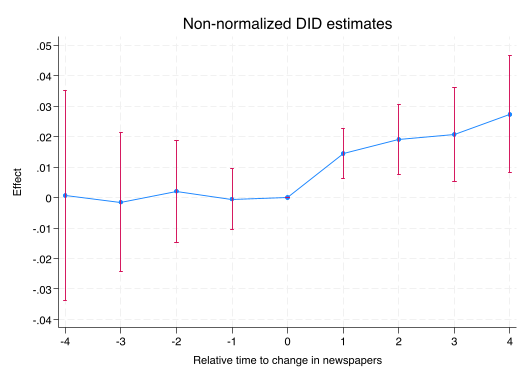

In [75]:
* Non-normalized event-study effects 
did_multiplegt_dyn prestout cnty90 year numdailies, ///
    effects(4) placebo(4) effects_equal(all)

* With graph
did_multiplegt_dyn prestout cnty90 year numdailies, effects(4) placebo(4) graphoptions(ylabel(-0.04(0.01)0.05) xlabel(-4(1)4) yscale(range(-0.04 0.05)) legend(off) xtitle(Relative time to change in newspapers) title(Non-normalized DID estimates) ytitle(Effect))
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphnewspapers_dCDH.pdf", replace


### 8.4 Trajectory Decomposition

The individual trajectories that make up the unnormalized average effects are analyzed.

In [76]:
* Analyzing the paths whose effect is averaged in the non-normalized event-study effects

did_multiplegt_dyn prestout cnty90 year numdailies, ///
    effects(1) design(0.8,console) graph_off

did_multiplegt_dyn prestout cnty90 year numdailies, ///
    effects(2) design(0.8,console) graph_off

did_multiplegt_dyn prestout cnty90 year numdailies, ///
    effects(4) design(0.8,console) graph_off




-------------------------------------------------------------------------------
> -
             Estimation of treatment effects: Event-study effects
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI          N 
-------------+-------------------------------------------------------
    Effect_1 |  .0144244   .0042477   .0060992   .0227497       5674 

             | Switchers 
-------------+----------
    Effect_1 |      1119 
-------------------------------------------------------------------------------
> -


-------------------------------------------------------------------------------
> -
               Average cumulative (total) effect per treatment unit
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI          N 
-------------+-------------------------------------------------------
  Av_tot_eff

### 8.5 Normalized Event Study

Dynamic effects are normalized to facilitate interpretation and comparison between periods.



-------------------------------------------------------------------------------
> -
             Estimation of treatment effects: Event-study effects
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI          N 
-------------+-------------------------------------------------------
    Effect_1 |  .0120186   .0035392   .0050819   .0189552       5674 
    Effect_2 |  .0082126   .0025136   .0032859   .0131392       4648 
    Effect_3 |  .0057192   .0021857   .0014354    .010003       3750 
    Effect_4 |  .0053873   .0019348   .0015951   .0091795       2980 

             | Switchers 
-------------+----------
    Effect_1 |      1119 
    Effect_2 |      1054 
    Effect_3 |       984 
    Effect_4 |       917 
-------------------------------------------------------------------------------
> -
Test of joint nullity of the effects : p-value = .00681389
Test of equality of the effects : p-value = 

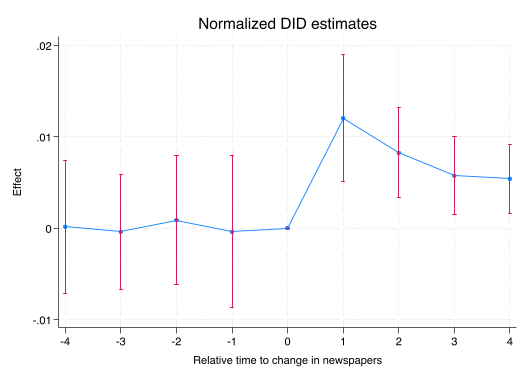

In [77]:
* Normalized event-study effects
did_multiplegt_dyn prestout cnty90 year numdailies, ///
    effects(4) placebo(4) normalized normalized_weights ///
    effects_equal(all)

* With graph
did_multiplegt_dyn prestout cnty90 year numdailies, effects(4) placebo(4) normalized normalized_weights effects_equal(all) graphoptions(ylabel(-0.01(0.01)0.02) xlabel(-4(1)4) yscale(range(-0.01 0.02)) legend(off) xtitle(Relative time to change in newspapers) title(Normalized DID estimates) ytitle(Effect))
graph export "/Users/karlavega/Documents/GitHub/did_book/Stata/graphnewspapers_dCDH_normalized.pdf", replace

### 8.6 Lagged Effects of Treatment Test

This test assesses whether treatment lags affect the outcome.

In [78]:
* Testing if the lagged number of newspapers affects turnout
did_multiplegt_dyn prestout cnty90 year numdailies ///
    if year<=first_change | same_treat_after_first_change==1, ///
    effects(2) effects_equal(all) same_switchers graph_off




-------------------------------------------------------------------------------
> -
             Estimation of treatment effects: Event-study effects
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI          N 
-------------+-------------------------------------------------------
    Effect_1 |    .01525   .0058956   .0036949   .0268052       5019 
    Effect_2 |  .0164091   .0073633   .0019773   .0308409       4101 

             | Switchers 
-------------+----------
    Effect_1 |       512 
    Effect_2 |       512 
-------------------------------------------------------------------------------
> -
Test of joint nullity of the effects : p-value = .02913029
Test of equality of the effects : p-value = .83016668


-------------------------------------------------------------------------------
> -
               Average cumulative (total) effect per treatment unit
----------------------------

### 8.7 Estimators without lagged treatment effects

Models are estimated that assume the absence of effects of past treatments on the current outcome.

                                  ---------------------------------------------
> -
                                   Number of observations     =            1546
> 6
                                   Estimation method          =  reg. adjustmen
> t
                                   Common support*            =   exact matchin
> g
                                  ---------------------------------------------
> -
-------------------------------------------------------------------------------
> -
                               Average Slope (AS)
-------------------------------------------------------------------------------
> -

             |  Estimate         SE      LB CI      UB CI  Switchers 
-------------+-------------------------------------------------------
          AS |  .0060678   .0016463    .002841   .0092947       4423 

             |   Stayers 
-------------+----------
          AS |     11043 
-------------------------------------------------------------------------

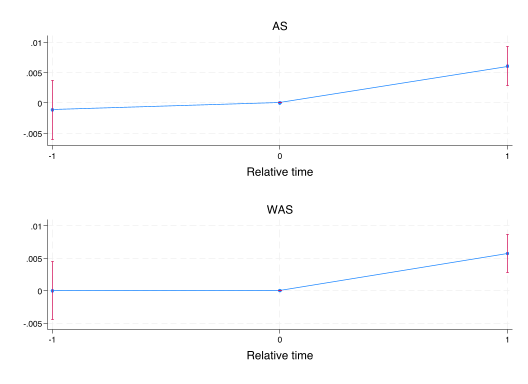

In [79]:
* Estimators assuming away effects of lagged treatments on the outcome
egen election_number = group(year)

did_multiplegt_stat prestout cnty90 election_number numdailies, ///
    placebo(1) exact_match

tab lag_numdailies if year==first_change
tab lag_numdailies if changedailies!=0 & changedailies!=. & year!=1868
